# Data Exploration
Explores `all_spectra.csv` and `ambient_spectra.csv`.

## Load Data
Reads both CSV files into DataFrames. The index column (unnamed) is dropped. Feature columns are the numeric wavelength channels (981–2969 nm), and the `polymer` column is treated as the class label. Separate feature matrices (`X`) and label series (`y`) are created for each dataset.

In [ ]:
# Import libraries for data manipulation, numerical operations, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both CSVs; the first column is an unnamed row index so it is dropped
all_spectra = pd.read_csv('all_spectra.csv', index_col=0)
ambient_spectra = pd.read_csv('ambient_spectra.csv', index_col=0)

# Identify the label column and collect all remaining columns as wavelength features
# Both all_spectra.csv and ambient_spectra.csv has label columns called "polymer"
label_col = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Split all_spectra into a feature matrix (X) and a label series (y)
X_all = all_spectra[wavelengths]
y_all = all_spectra[label_col]

# Split ambient_spectra into a feature matrix (X) and a label series (y)
X_amb = ambient_spectra[wavelengths]
y_amb = ambient_spectra[label_col]

# Print the shape and number of unique polymer classes for each dataset
print('all_spectra  :', X_all.shape, '| labels:', y_all.nunique(), 'unique') # count of unique polymer labels, such as "Sucrose", "Polyethylene", etc.
print('ambient_spectra:', X_amb.shape, '| labels:', y_amb.nunique(), 'unique') # label for all ambient particles are "AMB"

# Preview the first 5 rows of each DataFrame to inspect structure and values
print('\n=== all_spectra ===')
display(all_spectra.head())

print('\n=== ambient_spectra ===')
display(ambient_spectra.head())

all_spectra  : (1215, 535) | labels: 21 unique
ambient_spectra: (55, 535) | labels: 1 unique

=== all_spectra ===


,981.0,983.0,985.0,987.0,989.0,991.0,993.0,995.0,997.0,999.0,...,2953.0,2955.0,2957.0,2959.0,2961.0,2963.0,2965.0,2967.0,2969.0,polymer
0,-0.447035,-0.421266,-0.467836,-0.372833,-0.145153,0.130042,0.189127,0.155498,0.205391,0.153876,...,-0.682721,-0.876255,-0.868612,-0.687966,-0.724311,-0.715632,-0.514595,-0.280458,-0.347723,Sucrose
1,-0.815085,-0.512456,-0.297874,-0.198960,-0.148931,-0.163417,-0.028107,0.146969,0.169685,0.146503,...,-0.169201,-0.227428,-0.425777,-0.666376,-0.867979,-0.927873,-0.614046,0.066000,0.134807,Sucrose
2,-0.520710,-0.445017,-0.352656,-0.253250,-0.105821,-0.032574,-0.047475,0.040878,0.113861,0.036063,...,0.009823,-0.461010,-0.395581,-0.231158,-0.101210,-0.176790,-0.569805,-0.798102,-0.838369,Sucrose
3,-0.402060,-0.424283,-0.528735,-0.530170,-0.446972,-0.325313,-0.381953,-0.499918,-0.383397,-0.093098,...,0.329715,-0.129499,0.038654,0.899960,1.247222,1.547973,1.412458,0.660978,-0.348765,Sucrose
4,-0.132373,0.052544,0.249514,0.420353,0.532474,0.611563,0.665630,0.695106,0.699343,0.662427,...,-0.484919,-0.522236,-0.546862,-0.508035,-0.522078,-0.618666,-0.679660,-0.674599,-0.661172,Sucrose



=== ambient_spectra ===


,981.0,983.0,985.0,987.0,989.0,991.0,993.0,995.0,997.0,999.0,...,2953.0,2955.0,2957.0,2959.0,2961.0,2963.0,2965.0,2967.0,2969.0,polymer
0,-0.251032,0.057088,0.326262,0.089384,-0.242408,-0.409751,-0.376477,-0.359663,-0.387687,-0.072434,...,0.368362,-0.224098,-0.471189,-0.800029,-1.173113,-1.526537,-1.999653,-2.293553,-2.962726,AMB
1,-0.193453,-0.132233,-0.074012,-0.024453,0.007696,0.013761,-0.005324,-0.048586,-0.119315,-0.214456,...,0.042841,-0.030417,-0.099945,-0.164123,-0.218072,-0.271110,-0.329530,-0.390978,-0.444594,AMB
2,0.058470,0.195094,0.351237,0.524253,0.598981,0.542194,0.542284,0.720727,0.955020,1.047709,...,-0.846109,-0.863249,-0.737587,-0.942936,-1.187142,-1.123417,-1.165622,-1.337725,-1.504727,AMB
3,1.416711,1.515404,1.245176,0.942644,0.904935,1.255661,1.780324,2.087890,2.465446,2.677602,...,-0.468274,-0.524244,0.075100,0.043809,0.457775,0.583080,-0.074825,0.058442,1.181140,AMB
4,0.487867,-0.463680,-0.717249,0.034334,0.698976,0.820918,0.434080,0.570940,0.896830,0.304443,...,0.113302,-1.053788,0.378657,2.260423,2.555095,1.958677,1.369829,0.882091,-0.329586,AMB


**Results:** `all_spectra` contains 1,215 samples and `ambient_spectra` contains 55 samples. Both share the same 535 wavelength features spanning 981–2969 nm. The number of unique polymer classes is printed for each dataset.

## Basic Info
Displays the first few rows and summary statistics (`count`, `mean`, `std`, `min`, `max`, percentiles) for each dataset. This gives an initial sense of the data layout and the scale of intensity values across wavelength channels.

In [15]:
print('=== all_spectra ===')
display(all_spectra.head())
display(all_spectra.describe())

=== all_spectra ===


,981.0,983.0,985.0,987.0,989.0,991.0,993.0,995.0,997.0,999.0,...,2953.0,2955.0,2957.0,2959.0,2961.0,2963.0,2965.0,2967.0,2969.0,polymer
0,-0.447035,-0.421266,-0.467836,-0.372833,-0.145153,0.130042,0.189127,0.155498,0.205391,0.153876,...,-0.682721,-0.876255,-0.868612,-0.687966,-0.724311,-0.715632,-0.514595,-0.280458,-0.347723,Sucrose
1,-0.815085,-0.512456,-0.297874,-0.198960,-0.148931,-0.163417,-0.028107,0.146969,0.169685,0.146503,...,-0.169201,-0.227428,-0.425777,-0.666376,-0.867979,-0.927873,-0.614046,0.066000,0.134807,Sucrose
2,-0.520710,-0.445017,-0.352656,-0.253250,-0.105821,-0.032574,-0.047475,0.040878,0.113861,0.036063,...,0.009823,-0.461010,-0.395581,-0.231158,-0.101210,-0.176790,-0.569805,-0.798102,-0.838369,Sucrose
3,-0.402060,-0.424283,-0.528735,-0.530170,-0.446972,-0.325313,-0.381953,-0.499918,-0.383397,-0.093098,...,0.329715,-0.129499,0.038654,0.899960,1.247222,1.547973,1.412458,0.660978,-0.348765,Sucrose
4,-0.132373,0.052544,0.249514,0.420353,0.532474,0.611563,0.665630,0.695106,0.699343,0.662427,...,-0.484919,-0.522236,-0.546862,-0.508035,-0.522078,-0.618666,-0.679660,-0.674599,-0.661172,Sucrose


,981.0,983.0,985.0,987.0,989.0,991.0,993.0,995.0,997.0,999.0,...,2951.0,2953.0,2955.0,2957.0,2959.0,2961.0,2963.0,2965.0,2967.0,2969.0
count,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,...,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000
mean,-0.211360,-0.201605,-0.190217,-0.162251,-0.131913,-0.103779,-0.070505,-0.030613,-0.003671,-0.005490,...,0.691427,0.578062,0.497315,0.468964,0.438345,0.350153,0.227467,0.153115,0.104838,-0.002246
std,0.662271,0.682153,0.707522,0.719316,0.735971,0.749718,0.762693,0.785990,0.814502,0.820656,...,1.589442,1.520295,1.489074,1.533180,1.576125,1.596427,1.637002,1.609106,1.562084,1.530877
min,-3.053411,-2.869938,-2.877220,-3.148388,-2.381630,-2.275393,-2.575711,-1.655914,-1.591977,-1.732455,...,-5.190075,-4.914553,-5.447290,-5.193373,-6.935169,-6.406518,-8.008309,-8.691383,-6.863308,-7.724779
25%,-0.531892,-0.525640,-0.533220,-0.509409,-0.499216,-0.492710,-0.469493,-0.446230,-0.441408,-0.435599,...,-0.342094,-0.391204,-0.431275,-0.445131,-0.483079,-0.517330,-0.539489,-0.554135,-0.587694,-0.608599
50%,-0.329563,-0.336452,-0.333261,-0.324371,-0.312265,-0.305125,-0.291679,-0.276834,-0.276619,-0.269309,...,0.257029,0.229477,0.174919,0.125319,0.103734,0.062220,-0.002028,-0.070580,-0.128950,-0.169158
75%,-0.047312,-0.064648,-0.040333,-0.008703,0.014444,0.014865,0.081422,0.187661,0.235246,0.253585,...,1.655575,1.618012,1.482820,1.461291,1.471759,1.348601,1.130752,1.048626,0.894310,0.654802
max,2.887205,2.792415,3.445326,4.098689,4.570615,4.812158,5.078127,6.383225,7.714533,7.741908,...,6.865327,5.608909,6.716428,6.780961,7.530039,7.200979,7.763641,8.956605,8.488831,8.347582


**Results:** The head shows sample rows with wavelength intensity values and their corresponding polymer label. The `describe()` summary reveals the typical intensity range, central tendency, and spread across all wavelength channels for the full dataset.

In [16]:
print('=== ambient_spectra ===')
display(ambient_spectra.head())
display(ambient_spectra.describe())

=== ambient_spectra ===


,981.0,983.0,985.0,987.0,989.0,991.0,993.0,995.0,997.0,999.0,...,2953.0,2955.0,2957.0,2959.0,2961.0,2963.0,2965.0,2967.0,2969.0,polymer
0,-0.251032,0.057088,0.326262,0.089384,-0.242408,-0.409751,-0.376477,-0.359663,-0.387687,-0.072434,...,0.368362,-0.224098,-0.471189,-0.800029,-1.173113,-1.526537,-1.999653,-2.293553,-2.962726,AMB
1,-0.193453,-0.132233,-0.074012,-0.024453,0.007696,0.013761,-0.005324,-0.048586,-0.119315,-0.214456,...,0.042841,-0.030417,-0.099945,-0.164123,-0.218072,-0.271110,-0.329530,-0.390978,-0.444594,AMB
2,0.058470,0.195094,0.351237,0.524253,0.598981,0.542194,0.542284,0.720727,0.955020,1.047709,...,-0.846109,-0.863249,-0.737587,-0.942936,-1.187142,-1.123417,-1.165622,-1.337725,-1.504727,AMB
3,1.416711,1.515404,1.245176,0.942644,0.904935,1.255661,1.780324,2.087890,2.465446,2.677602,...,-0.468274,-0.524244,0.075100,0.043809,0.457775,0.583080,-0.074825,0.058442,1.181140,AMB
4,0.487867,-0.463680,-0.717249,0.034334,0.698976,0.820918,0.434080,0.570940,0.896830,0.304443,...,0.113302,-1.053788,0.378657,2.260423,2.555095,1.958677,1.369829,0.882091,-0.329586,AMB


,981.0,983.0,985.0,987.0,989.0,991.0,993.0,995.0,997.0,999.0,...,2951.0,2953.0,2955.0,2957.0,2959.0,2961.0,2963.0,2965.0,2967.0,2969.0
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,...,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,0.048225,0.140107,0.203455,0.311278,0.354492,0.379780,0.452916,0.538625,0.633354,0.681562,...,-0.192535,-0.104842,-0.154077,-0.293509,-0.313733,-0.326678,-0.264839,-0.205023,-0.233485,-0.277071
std,1.026320,1.000669,1.078338,1.145817,1.189061,1.198306,1.225491,1.251547,1.267460,1.318292,...,0.719343,0.740628,0.881513,0.788091,0.707347,0.760866,0.986863,1.102079,1.332453,1.358940
min,-2.075153,-1.239819,-1.410168,-1.276705,-1.328707,-1.416580,-1.372241,-1.260568,-1.237304,-1.163227,...,-2.304054,-1.702443,-2.104730,-2.479472,-1.795047,-1.948756,-2.343287,-3.084610,-4.163255,-3.956088
25%,-0.498519,-0.461282,-0.379543,-0.392644,-0.370364,-0.406168,-0.336516,-0.287503,-0.219713,-0.299274,...,-0.628531,-0.522809,-0.714742,-0.694840,-0.770431,-0.693397,-0.745418,-0.657992,-0.753257,-0.723359
50%,-0.242139,-0.137679,-0.074012,0.034334,-0.000687,0.001471,-0.018084,-0.048586,0.006643,0.201259,...,-0.383724,-0.294239,-0.307736,-0.370754,-0.424265,-0.412155,-0.403068,-0.380296,-0.390978,-0.444594
75%,0.283341,0.373075,0.614653,0.950799,0.910871,0.864013,0.995480,1.218870,1.300512,1.741933,...,0.287173,0.114238,0.128182,0.057331,0.118217,0.051093,0.023797,0.239138,0.068171,-0.026637
max,3.132434,3.215265,3.620410,4.493845,4.689085,4.530196,4.469006,4.099089,4.064971,4.146511,...,1.458669,2.512138,2.362030,1.686439,2.260423,2.555095,4.233434,3.663251,6.235569,5.727880


**Results:** The ambient dataset is much smaller (55 samples). Comparing its `describe()` output to `all_spectra` highlights differences in intensity scale and variance, which may indicate ambient spectra have distinct spectral characteristics from the broader collection.

## Label Distributions
Plots bar charts of sample counts per polymer class for both datasets. This reveals whether classes are balanced or imbalanced, and whether the same polymer types appear in both files.

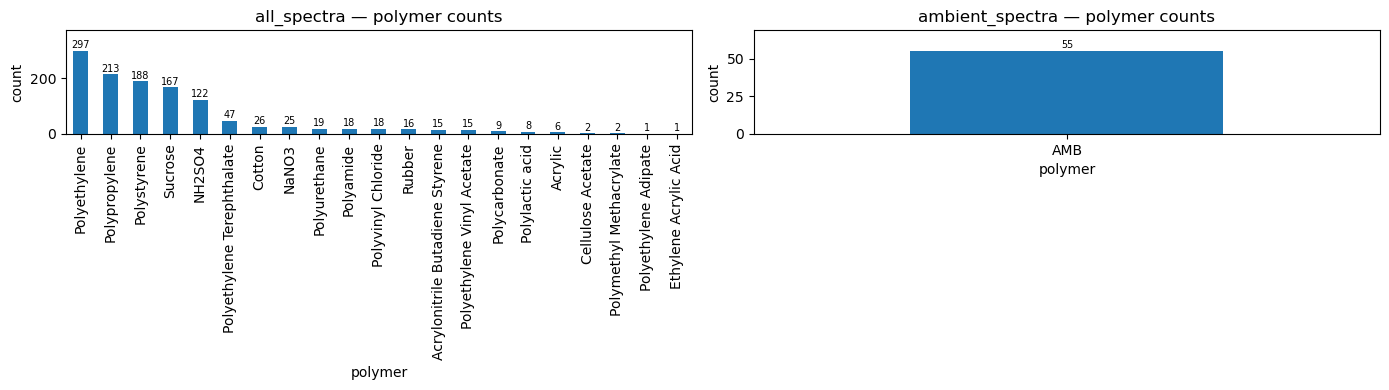

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# display the count of each polymer label in all_spectra.csv
all_counts = y_all.value_counts()
all_counts.plot(kind='bar', ax=axes[0], title='all_spectra — polymer counts')
axes[0].set_xlabel('polymer')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=90)
for i, v in enumerate(all_counts):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontsize=7)
axes[0].set_ylim(0, all_counts.max() * 1.25)

# display the count of "AMB" label in ambient_spectra.csv
amb_counts = y_amb.value_counts()
amb_counts.plot(kind='bar', ax=axes[1], title='ambient_spectra — polymer counts')
axes[1].set_xlabel('polymer')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(amb_counts):
    axes[1].text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=7)
axes[1].set_ylim(0, amb_counts.max() * 1.25)

plt.tight_layout()
plt.show()

**Results:**

**all_spectra (left chart)** — 21 polymer classes, heavily imbalanced:
- The top 3 classes dominate: **Polyethylene** (297), **Polypropylene** (213), and **Polystyrene** (188) together account for ~57% of all samples
- **Sucrose** (167) and **NH2SO4** (122) are the next largest
- The remaining 16 classes are sparse, with several having fewer than 10 samples (e.g., Cellulose Acetate: 2, Polyethylene Adipate: 1)
- The distribution has a long right-skewed tail — a significant class imbalance problem for modeling

**ambient_spectra (right chart)** — a single class:
- All 55 samples belong to one class: **AMB** (ambient)
- This dataset represents only the background/ambient condition with no polymer variation

**Key takeaway:** `all_spectra` is highly imbalanced with rare classes that may be difficult to model, while `ambient_spectra` is a uniform single-class dataset representing the baseline ambient signal.

## Missing Values
Checks the total number of missing (`NaN`) values across all columns in both datasets. Missing values in spectral data could indicate sensor dropouts or preprocessing gaps and would need to be handled before modeling.

In [28]:
print('all_spectra missing values:   ', all_spectra.isnull().sum().sum())
print('ambient_spectra missing values:', ambient_spectra.isnull().sum().sum())

all_spectra missing values:    0
ambient_spectra missing values: 0


**Results:** A count of 0 for both datasets means the data is complete with no missing values, and no imputation is necessary before modeling.

## Value Range per Dataset
Computes global min, max, mean, and standard deviation across all intensity values in each dataset. This indicates whether the data is already normalized, and whether the two datasets share a similar intensity scale.

In [29]:
for name, X in [('all_spectra', X_all), ('ambient_spectra', X_amb)]:
    print(f'{name} — min: {X.values.min():.4f}  max: {X.values.max():.4f}  mean: {X.values.mean():.4f}  std: {X.values.std():.4f}')

all_spectra — min: -8.6914  max: 10.3931  mean: -0.0000  std: 1.0000
ambient_spectra — min: -4.1633  max: 8.3286  mean: -0.0000  std: 1.0000


**Results:**

Both datasets are **already normalized** (z-score normalized):

- **mean ≈ 0.0000** — the intensities have been centered around zero, meaning the average signal has been subtracted out
- **std = 1.0000** — the intensities have been scaled so that one standard deviation equals 1, making the spread uniform
- **min/max** — `all_spectra` ranges from -8.69 to 10.39, and `ambient_spectra` from -4.16 to 8.33. These are standard deviation units from the mean, not raw sensor counts

**Key takeaway:** You don't need to normalize the data before modeling — it's already been preprocessed. The two datasets are also on the same scale, so they can be directly compared or combined. The extreme values (e.g., -8.69, 10.39) are outliers sitting many standard deviations from the mean.